# Introduction

## Problem Statement
Customers have the freedom to choose the telecommunications provider that best meets their needs and may switch from their current provider to another. This behavior is known as **customer churn**. Customer churn can lead to a significant loss of revenue for telecommunication companies, making it a critical business problem. Therefore, predicting customer churn is essential so that companies can develop effective strategies to retain customers and reduce churn.

## Objective
To build a machine learning model capable of predicting whether a customer is likely to churn.

## Business Metric
- **Churn Rate**

## Dataset Feature Description

| Feature Name | Description |
|-------------|-------------|
| state | U.S. state where the customer resides |
| account_length | Total number of months the customer has been with the telecom provider |
| area_code | Customer's area code |
| international_plan | Indicates whether the customer has an international calling plan |
| voice_mail_plan | Indicates whether the customer has a voice mail plan |
| number_vmail_messages | Total number of voice mail messages |
| total_day_minutes | Total minutes used during daytime calls |
| total_day_calls | Total number of daytime calls |
| total_day_charge | Total charges for daytime calls |
| total_eve_minutes | Total minutes used during evening calls |
| total_eve_calls | Total number of evening calls |
| total_eve_charge | Total charges for evening calls |
| total_night_minutes | Total minutes used during night calls |
| total_night_calls | Total number of night calls |
| total_night_charge | Total charges for night calls |
| total_intl_minutes | Total minutes used for international calls |
| total_intl_calls | Total number of international calls |
| total_intl_charge | Total charges for international calls |
| number_customer_service_calls | Total number of calls made to customer service |
| churn | Indicates whether the customer has churned (Target Variable) |

# **Load Dataset**

In [1]:
# import library
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt   
%matplotlib inline
import warnings                
warnings.filterwarnings("ignore")
from IPython.display import clear_output

In [2]:
# Load the dataset

df = pd.read_csv('Data_Churn.csv')


In [3]:
df.columns

Index(['state', 'account_length', 'area_code', 'international_plan',
       'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes',
       'total_day_calls', 'total_day_charge', 'total_eve_minutes',
       'total_eve_calls', 'total_eve_charge', 'total_night_minutes',
       'total_night_calls', 'total_night_charge', 'total_intl_minutes',
       'total_intl_calls', 'total_intl_charge',
       'number_customer_service_calls', 'churn'],
      dtype='object')

# **Exploratory Data Analysis**

## Data Overview
---

In [4]:
df.shape

(4250, 20)

In [5]:
# view data summary
list_item = []
for col in df.columns:
    list_item.append([col, df[col].dtype, 
                      df[col].isna().sum(), 
                      round(100*df[col].isna().sum()/len(df[col]), 2), 
                      df[col].nunique(), 
                      df[col].unique()[:10]])

df_desc = pd.DataFrame(data=list_item, columns='feature, datatype, null_values, null_percentage, unique_values, unique_sample'.split(","))
df_desc

,feature,datatype,null_values,null_percentage,unique_values,unique_sample
0,state,object,0,0.0,51,"[OH, NJ, OK, MA, MO, LA, WV, IN, RI, IA]"
1,account_length,int64,0,0.0,215,"[107, 137, 84, 75, 121, 147, 117, 141, 65, 74]"
2,area_code,object,0,0.0,3,"[area_code_415, area_code_408, area_code_510]"
3,international_plan,object,0,0.0,2,"[no, yes]"
4,voice_mail_plan,object,0,0.0,2,"[yes, no]"
5,number_vmail_messages,int64,0,0.0,46,"[26, 0, 24, 37, 27, 33, 39, 25, 30, 41]"
6,total_day_minutes,float64,0,0.0,1843,"[161.6, 243.4, 299.4, 166.7, 218.2, 157.0, 184..."
7,total_day_calls,int64,0,0.0,120,"[123, 114, 71, 113, 88, 79, 97, 84, 137, 127]"
8,total_day_charge,float64,0,0.0,1843,"[27.47, 41.38, 50.9, 28.34, 37.09, 26.69, 31.3..."
9,total_eve_minutes,float64,0,0.0,1773,"[195.5, 121.2, 61.9, 148.3, 348.5, 103.1, 351...."


In [6]:
# Check Duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
numeric = []
for col in df.columns:
  if df[col].dtype != object:
    numeric.append(col)

print(numeric)
print(f'number of numeric features :{len(numeric)}')

['account_length', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'number_customer_service_calls']
number of numeric features :15


In [8]:
categorical = []
for col in df.columns:
  if df[col].dtype == object:
    categorical.append(col)

print(categorical)
print(f'number of numeric Categorical :{len(categorical)}')

['state', 'area_code', 'international_plan', 'voice_mail_plan', 'churn']
number of numeric Categorical :5


**Key Takeaways:**
- The dataset consists of **4,250 rows** and **20 features** (**15 numerical features** and **5 categorical features**).
- The dataset contains **no null or missing values**.
- The dataset contains **no duplicate records**.

## Statistical Summary
---

In [9]:
# Summary statistics of numerical features
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
account_length,4250.0,100.24,39.70,1.0,73.00,100.00,127.00,243.00
number_vmail_messages,4250.0,7.63,13.44,0.0,0.00,0.00,16.00,52.00
total_day_minutes,4250.0,180.26,54.01,0.0,143.33,180.45,216.20,351.50
total_day_calls,4250.0,99.91,19.85,0.0,87.00,100.00,113.00,165.00
total_day_charge,4250.0,30.64,9.18,0.0,24.36,30.68,36.75,59.76
total_eve_minutes,4250.0,200.17,50.25,0.0,165.92,200.70,233.78,359.30
total_eve_calls,4250.0,100.18,19.91,0.0,87.00,100.00,114.00,170.00
total_eve_charge,4250.0,17.02,4.27,0.0,14.10,17.06,19.87,30.54
total_night_minutes,4250.0,200.53,50.35,0.0,167.22,200.45,234.70,395.00
total_night_calls,4250.0,99.84,20.09,0.0,86.00,100.00,113.00,175.00


### Key Takeaways

- The dataset contains **4,250 records**, and all numerical features have complete values.
- The average customer account length is around **100 months**.
- Most customers have **0 voice mail messages**, indicating many do not use the voice mail service.
- The average daily, evening, and night call durations are approximately **180, 200, and 200 minutes**, respectively.
- The average number of customer service calls is **1.56**, while the maximum is **9**, suggesting a few customers contact support frequently.
- Some features have a minimum value of **0**, which may represent valid customer behavior and should be verified during EDA.
- The wide range between minimum and maximum values in several features indicates that **outlier analysis** should be performed.

In [10]:
# Summary statistics of categorical features
df[categorical].describe().T

,count,unique,top,freq
state,4250,51,WV,139
area_code,4250,3,area_code_415,2108
international_plan,4250,2,no,3854
voice_mail_plan,4250,2,no,3138
churn,4250,2,no,3652


**Key Takeaways:**
- The majority of customers **did not churn**.

## Analyzing Feature
---

### Feature Target

Text(0.5, 1.0, 'Percentage of Customer Churn')

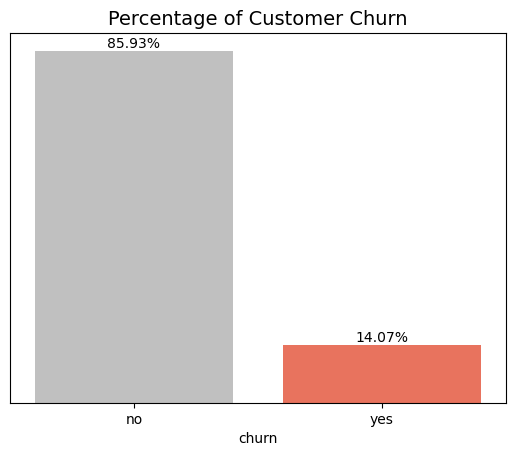

In [11]:
# Count churn classes
counts = df['churn'].value_counts()

# Convert counts to percentages
percentages = counts / counts.sum() * 100

# Plot churn percentage distribution
ax = sns.barplot(x=counts.index, y=percentages, palette=['silver', 'tomato'])

# Add percentage labels
for i, v in enumerate(percentages):
    ax.text(i, v, f'{v:.2f}%', ha='center', va='bottom')

# Clean up the chart
ax.set_yticks([])
plt.ylabel('')
plt.title('Percentage of Customer Churn', fontsize=14)

### Univariate Analysis 

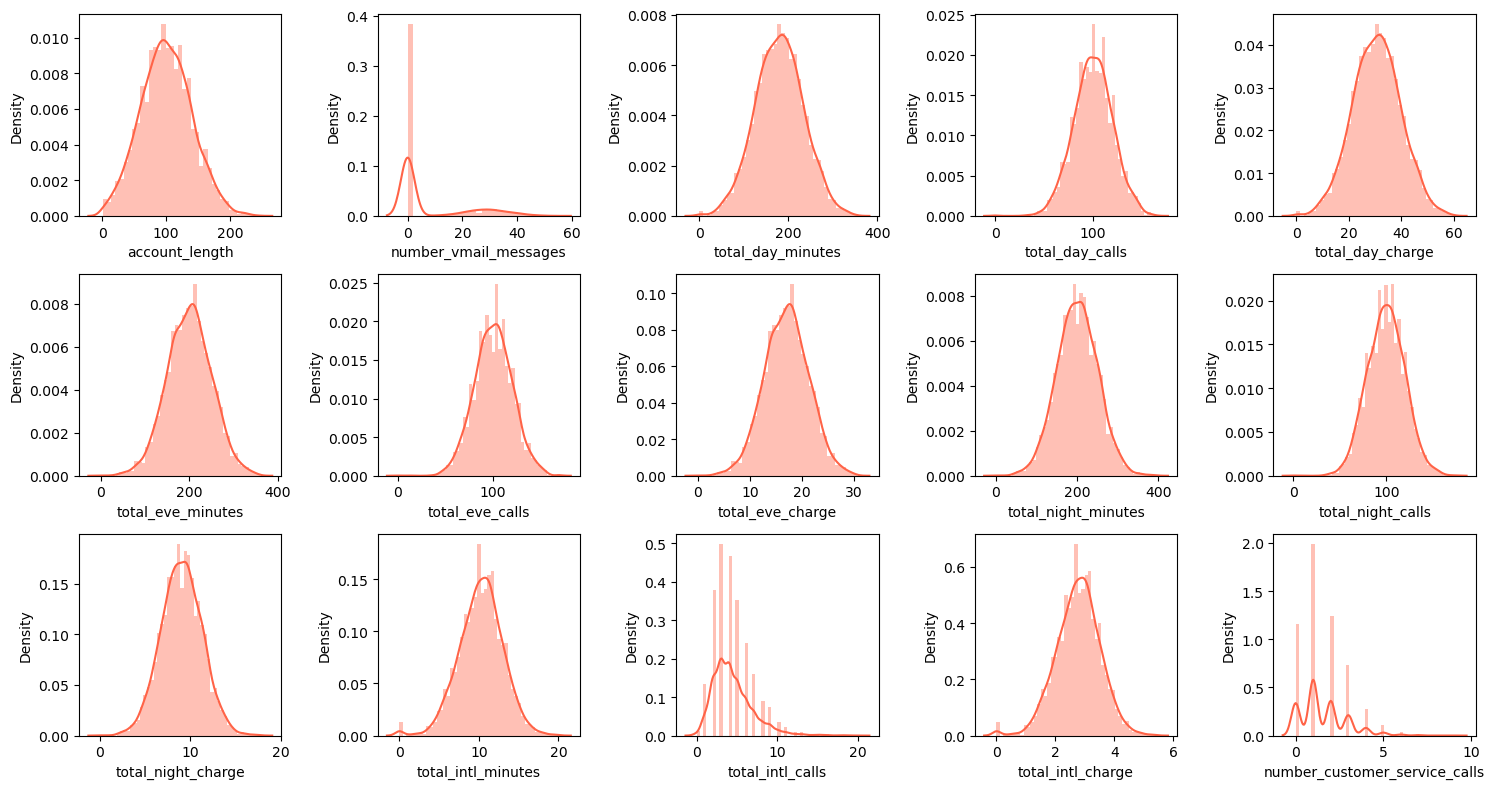

In [12]:
# Plot the distribution of all numerical features

plt.figure(figsize=(15, 8))

for i in range(len(numeric)):
    plt.subplot(3, 5, i + 1)

    # Distribution plot
    sns.distplot(df[numeric[i]], color='tomato')

    plt.tight_layout()

**Key Takeaways:**
- Overall, the data appears to be **approximately normally distributed**.
- The features `number_vmail_messages`, `total_intl_calls`, and `number_customer_service_calls` exhibit **positively skewed distributions**.

### Bivariate Analysis 

This analysis compares the distribution of each numerical feature between churned and non-churned customers to identify features related to customer churn.

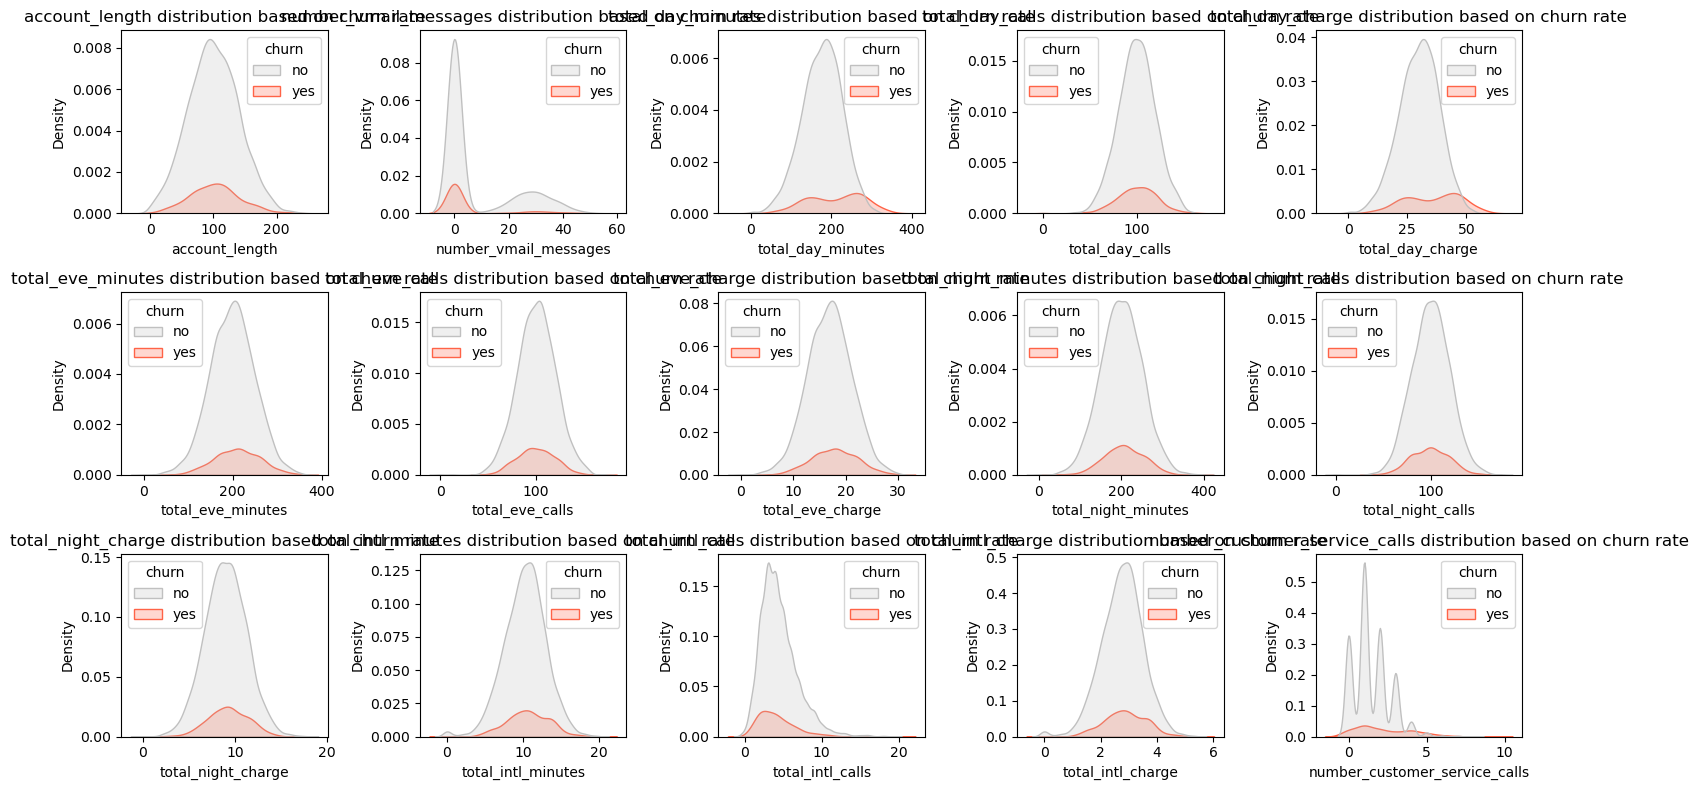

In [13]:
plt.figure(figsize=(15, 8))
for i in range(0, len(numeric)):
    plt.subplot(3, 5, i+1)
    sns.kdeplot(df, x=df[numeric[i]], hue=df['churn'], palette = ['silver', 'tomato'], 
                fill=True).set(title=f'{numeric[i]} distribution based on churn rate')
    plt.tight_layout()

### Categorical Feature Analysis

The following functions are used to calculate churn percentages and generate visualizations for categorical features.

In [14]:
# Calculate churn ratios and create a pivot table
def ratio_with_target(feats):
    ratio_df = df.groupby([feats, 'churn']).agg({'account_length': 'count'}).reset_index()
    ratio_df['ratio'] = ratio_df.groupby(feats).apply(
        lambda x: round(x.account_length / x.account_length.sum() * 100, 0)
    ).values.astype(int)
    ratio_df = ratio_df.pivot_table(index=feats, columns='churn', values='ratio')
    ratio_df = ratio_df.sort_values(by=['yes'], ascending=False)
    return ratio_df

# ---------------------------------------------------------------------------------------------------------

# Visualize customer churn distribution and ratios
def visualization(feature, title):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # Customer count by churn status
    ax[0].set_title(f'Churn by {title}\n', fontsize=14)
    sns.countplot(
        x=feature,
        data=df,
        hue='churn',
        palette=['silver', 'tomato'],
        ax=ax[0]
    )
    ax[0].bar_label(ax[0].containers[0], fontsize=14)
    ax[0].bar_label(ax[0].containers[1], fontsize=14)
    ax[0].set_yticks([])
    ax[0].set_xlabel('')
    ax[0].set_ylabel('')

    # Churn percentage by category
    ax[1].set_title(f'Ratio of Churn by {title}\n', fontsize=14)
    ratio_with_target(feature).plot(
        kind='barh',
        stacked=True,
        color=['silver', 'tomato'],
        ax=ax[1]
    )

    for p in ax[1].patches:
        left, bottom, width, height = p.get_bbox().bounds
        if width != 0:
            ax[1].annotate(
                f'{round(width, 2)}%',
                xy=(left + width / 2, bottom + height / 2),
                ha='center',
                va='center',
                fontsize=14
            )

    plt.legend([])
    ax[1].set_xticks([])
    ax[1].set_xlabel('')
    ax[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

### Categorical Feature Analysis

To avoid writing the same code multiple times, two functions are created.

- `ratio_with_target()` calculates the churn percentage for each category.
- `visualization()` displays both the customer count and churn percentage for a selected feature.

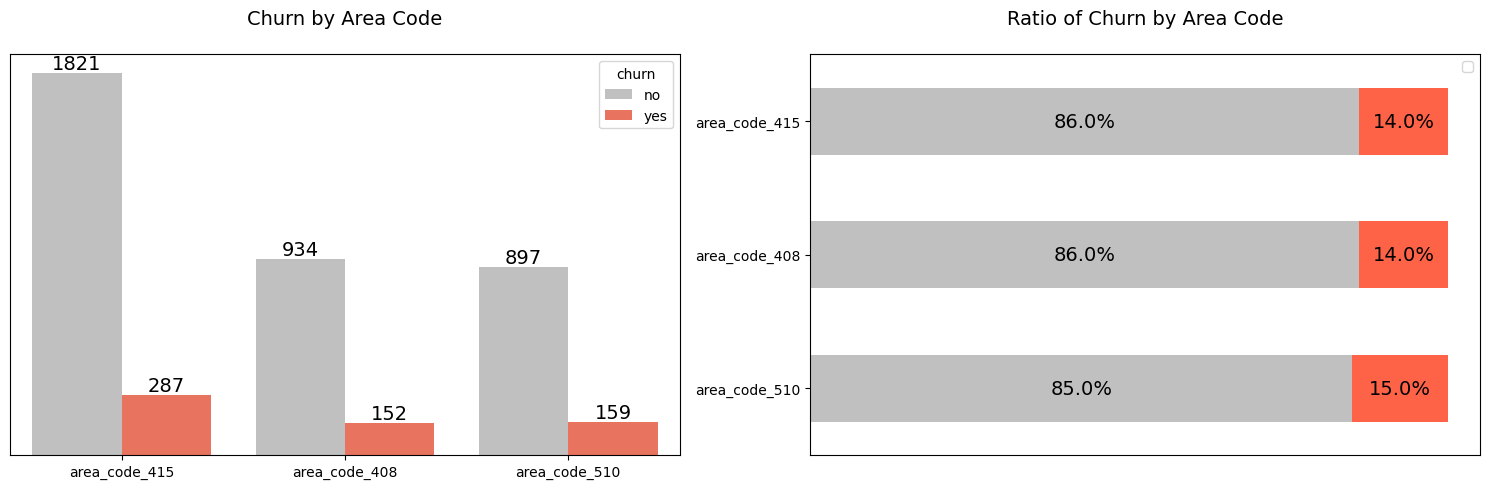

In [15]:
visualization('area_code', 'Area Code')

**Key Takeaways:**
- The majority of customers are from **Area Code 415**.
- The customer churn rate is **consistent across all area codes**, ranging from approximately **14% to 15%**.

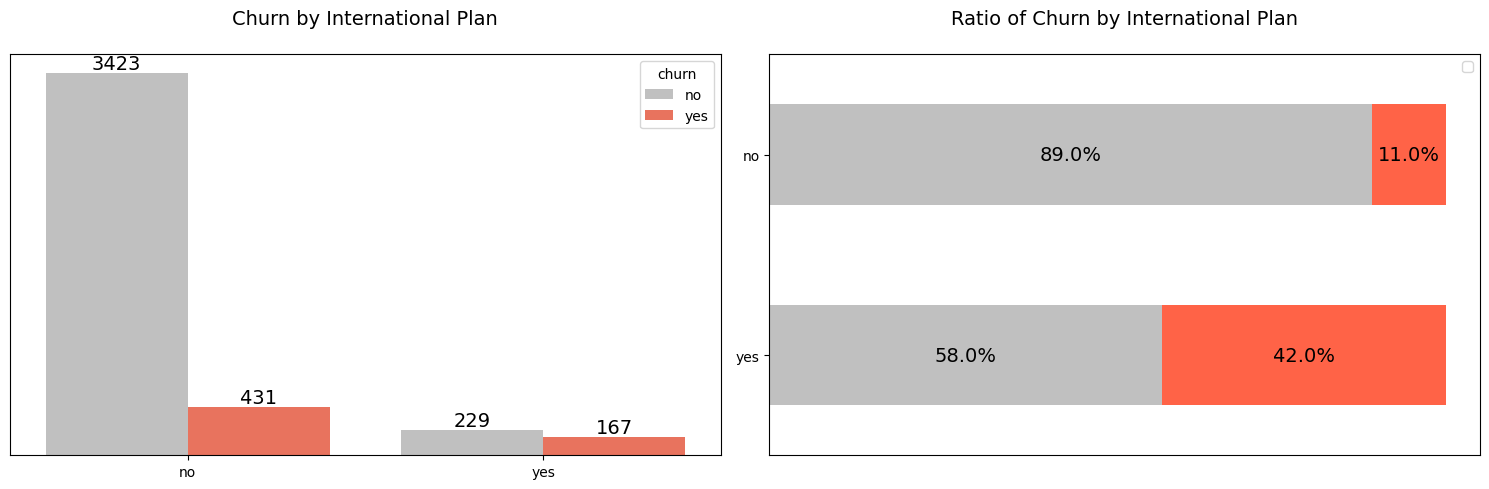

In [16]:
visualization('international_plan', 'International Plan')

**Key Takeaways:**
- Although the number of customers with an **International Plan** is relatively low, **42% of them churned**.
- In contrast, the churn rate among customers **without an International Plan** is only **11%**.

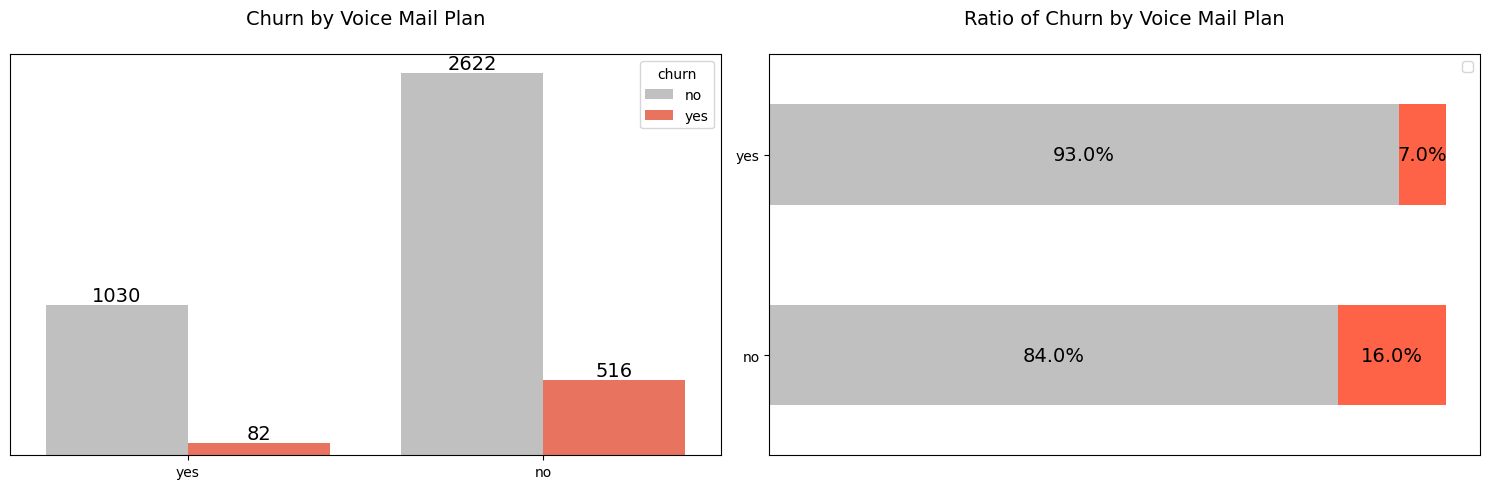

In [17]:
visualization('voice_mail_plan', 'Voice Mail Plan')

**Key Takeaways:**
- Similarly, although the number of customers with a **Voice Mail Plan** is relatively low, they exhibit a **higher churn rate of 16%** compared to customers **without a Voice Mail Plan**.

### Multivariate Analysis

In [18]:
df.columns

Index(['state', 'account_length', 'area_code', 'international_plan',
       'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes',
       'total_day_calls', 'total_day_charge', 'total_eve_minutes',
       'total_eve_calls', 'total_eve_charge', 'total_night_minutes',
       'total_night_calls', 'total_night_charge', 'total_intl_minutes',
       'total_intl_calls', 'total_intl_charge',
       'number_customer_service_calls', 'churn'],
      dtype='object')

#### *Calls in day*
---

In [19]:
print('Average charge per minutes in day call: {:.2f}'.format(df['total_day_charge'].mean()/df['total_day_minutes'].mean()))
print('Average minutes per calls in day call: {:.2f}'.format(df['total_day_minutes'].mean()/df['total_day_calls'].mean()))


Average charge per minutes in day call: 0.17
Average minutes per calls in day call: 1.80


#### *Calls in evening*
---

In [20]:
print('Average charge per minutes in evening call: {:.2f}'.format(df['total_eve_charge'].mean()/df['total_eve_minutes'].mean()))
print('Average minutes per calls in evening call: {:.2f}'.format(df['total_eve_minutes'].mean()/df['total_eve_calls'].mean()))


Average charge per minutes in evening call: 0.09
Average minutes per calls in evening call: 2.00


#### *Calls in night*
---

In [21]:
print('Average charge per minutes in night call: {:.2f}'.format(df['total_night_charge'].mean()/df['total_night_minutes'].mean()))
print('Average minutes per calls in night call: {:.2f}'.format(df['total_night_minutes'].mean()/df['total_night_calls'].mean()))

Average charge per minutes in night call: 0.05
Average minutes per calls in night call: 2.01


#### *International calls*
---

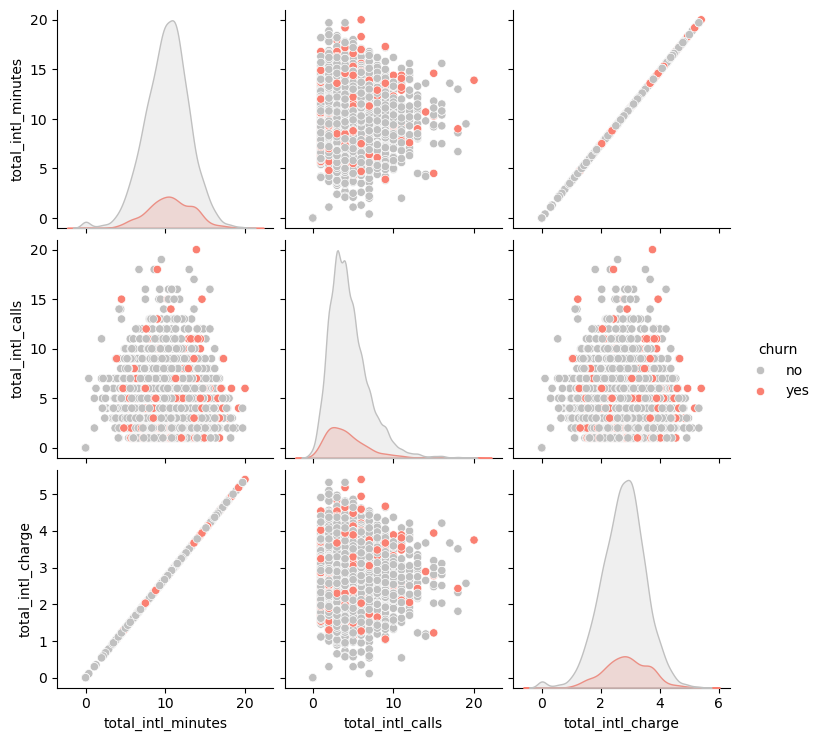

In [22]:
sns.pairplot(df[['total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'churn']], hue = 'churn', palette=['silver', 'salmon'])

### Pairwise Relationship Analysis

This pair plot is used to examine the relationship between `total_day_minutes`, `total_day_calls`, and `total_day_charge` while comparing churned and non-churned customers.

In [23]:
print('Average charge per minutes in international call: {:.2f}'.format(df['total_intl_charge'].mean()/df['total_intl_minutes'].mean()))
print('Average minutes per calls in international call: {:.2f}'.format(df['total_intl_minutes'].mean()/df['total_intl_calls'].mean()))

Average charge per minutes in international call: 0.27
Average minutes per calls in international call: 2.32


# **Data Prepocessing**

## Handling Outlier
---

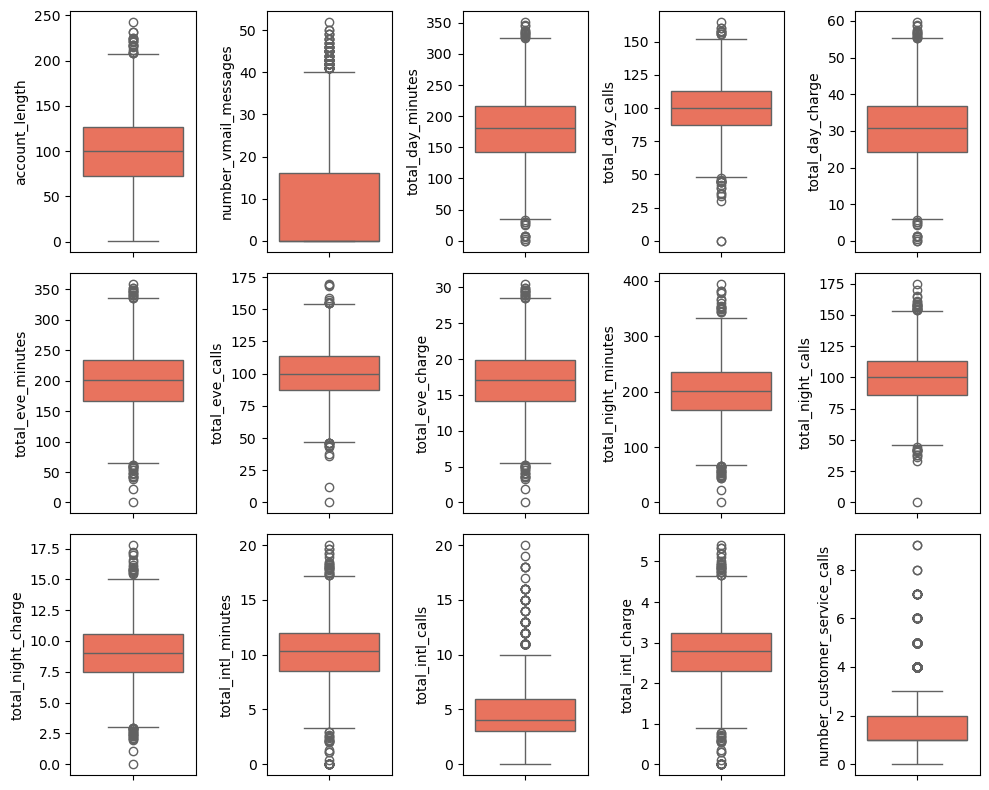

In [24]:
#check outlier
plt.figure(figsize=(10, 8))
for i in range (0,len(numeric)):
  plt.subplot(3, 5, i+1)
  num = numeric[i]
  sns.boxplot(y=df[num], color='tomato')
  # plt.figure(figsize=(3,3))
  plt.tight_layout()

**Key Takeaways:**
- Overall, the dataset contains **outliers**, but they appear to be **reasonable observations** rather than extreme values or anomalies resulting from data entry errors.
- Therefore, **no outlier treatment was performed**.

## Feature Encoding
---

In [25]:
df_en = df.copy()

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# ----------------------
for col in df_en.columns:
    if df_en[col].dtype == 'O':
        df_en[col] = le.fit_transform(df_en[col])

In [92]:
print(df.columns.tolist())

['state', 'account_length', 'area_code', 'international_plan', 'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'number_customer_service_calls', 'churn']


In [27]:
df_en['churn'].value_counts()

churn
0    3652
1     598
Name: count, dtype: int64

### Feature Selection
---

### Correlation Heatmap

A correlation heatmap is created to analyze the relationship between numerical features. The upper triangle is hidden to avoid duplicate values, making the visualization cleaner and easier to interpret.

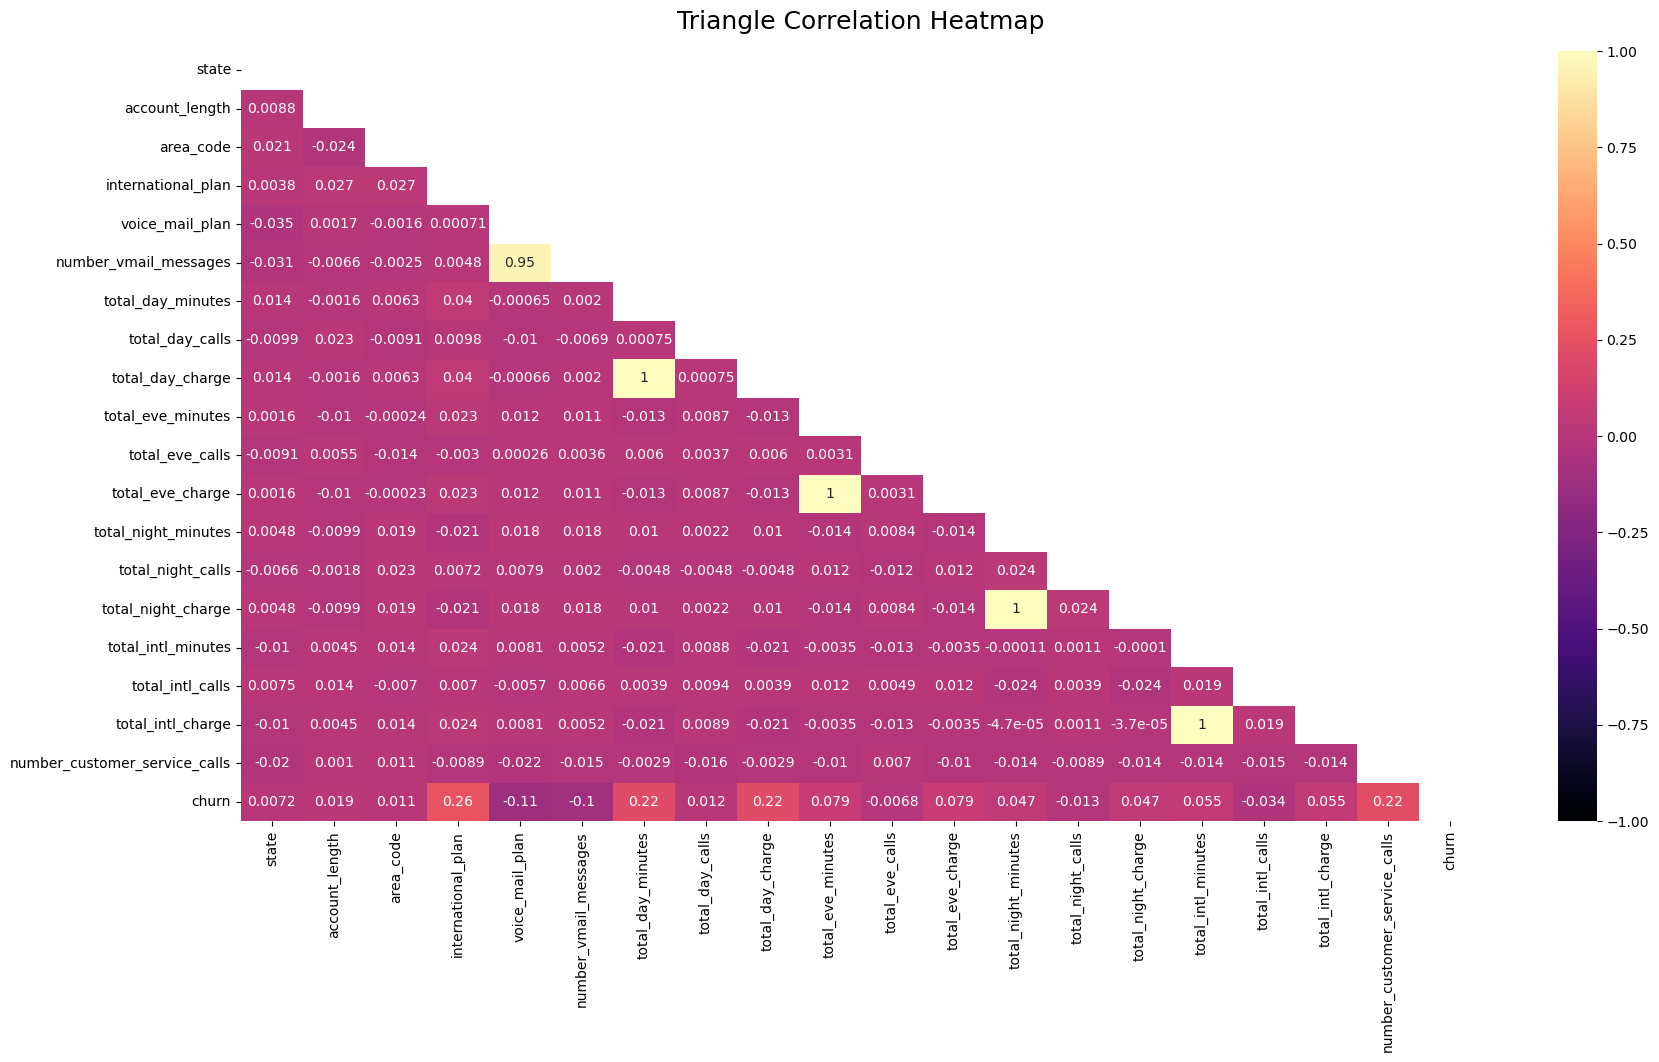

In [28]:
plt.figure(figsize=(20, 10))
corr_matrix = df_en.corr()
mask = np.triu(np.ones_like(corr_matrix,dtype=np.bool))
heatmap = sns.heatmap(corr_matrix, mask=mask, vmin=-1, vmax=1, annot=True, cmap='magma')
heatmap.set_title('Triangle Correlation Heatmap', fontdict={'fontsize':18}, pad=16);

In [29]:
# Remove redundant features from the dataset
redundant_feats = [
    'total_day_minutes',
    'total_eve_minutes',
    'total_night_minutes',
    'total_intl_minutes',
    'number_vmail_messages',
    'state'
]

df_en.drop(columns=redundant_feats, inplace=True)

In [30]:
df_en.corr().abs()['churn'].sort_values(ascending=False)

churn                            1.000000
international_plan               0.259053
number_customer_service_calls    0.221220
total_day_charge                 0.215263
voice_mail_plan                  0.114643
total_eve_charge                 0.078852
total_intl_charge                0.055177
total_night_charge               0.046641
total_intl_calls                 0.034334
account_length                   0.019378
total_night_calls                0.012699
total_day_calls                  0.011640
area_code                        0.010696
total_eve_calls                  0.006817
Name: churn, dtype: float64

In [31]:
df_en.sample(5).T

,437,2541,1,510,1625
account_length,95.00,177.00,137.00,79.00,100.00
area_code,1.00,1.00,1.00,2.00,0.00
international_plan,0.00,0.00,0.00,0.00,0.00
voice_mail_plan,1.00,0.00,0.00,0.00,0.00
total_day_calls,126.00,91.00,114.00,119.00,94.00
total_day_charge,6.95,45.24,41.38,22.13,12.04
total_eve_calls,90.00,79.00,110.00,121.00,102.00
total_eve_charge,11.34,19.14,10.30,24.73,18.33
total_night_calls,91.00,58.00,104.00,140.00,125.00
total_night_charge,11.89,10.11,7.32,8.77,10.39


# **Modeling**

## Split Train Test
---

In [32]:
df_model = df_en.copy()

In [33]:
X = df_model.drop(columns='churn').copy()
y = df_model['churn'].copy()

In [93]:
print(X.columns.tolist())

['account_length', 'area_code', 'international_plan', 'voice_mail_plan', 'total_day_calls', 'total_day_charge', 'total_eve_calls', 'total_eve_charge', 'total_night_calls', 'total_night_charge', 'total_intl_calls', 'total_intl_charge', 'number_customer_service_calls']


In [94]:
print(df_model.dtypes)

account_length                     int64
area_code                          int64
international_plan                 int64
voice_mail_plan                    int64
total_day_calls                    int64
total_day_charge                 float64
total_eve_calls                    int64
total_eve_charge                 float64
total_night_calls                  int64
total_night_charge               float64
total_intl_calls                   int64
total_intl_charge                float64
number_customer_service_calls      int64
churn                              int64
dtype: object


In [34]:
from sklearn.model_selection import train_test_split
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
print(X_train.shape, X_test.shape)

(2975, 13) (1275, 13)


In [35]:
y_train.value_counts()

churn
0    2550
1     425
Name: count, dtype: int64

- The target feature is imbalanced; therefore, **K-Fold cross-validation** can be used during model training to improve the robustness of model evaluation.

## Standardization
---

In [36]:
# Standardize the features using statistics computed from the training set
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Expriment
---

### Define Function

In [37]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Evaluate the trained model
def evaluate_model(model):

    # Predict class labels for the test set
    y_pred = model.predict(X_test)

    # Predict class probabilities
    y_pred_proba = model.predict_proba(X_test)
    y_train_proba = model.predict_proba(X_train)

    # Generate classification report
    report = classification_report(y_test, y_pred)

    # ROC-AUC scores
    test_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    train_auc = roc_auc_score(y_train, y_train_proba[:, 1])

    print("MODEL EVALUATION\n")
    print(report)
    print("-" * 55)
    print(f"Test ROC-AUC Score : {test_auc:.4f}")
    print(f"Train ROC-AUC Score: {train_auc:.4f}")
    print("-" * 55)

    plot_confusion_matrix(model)


# -----------------------------------------------------------------------------

# Plot the confusion matrix
def plot_confusion_matrix(model):

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Labels for each cell
    group_names = ['TN', 'FP', 'FN', 'TP']
    group_counts = [f'{value:.0f}' for value in cm.flatten()]
    group_percentages = [f'{value:.2%}' for value in cm.flatten() / np.sum(cm)]

    labels = [
        f'{name}\n{count}\n{percent}'
        for name, count, percent in zip(
            group_names,
            group_counts,
            group_percentages
        )
    ]

    labels = np.asarray(labels).reshape(2, 2)

    plt.figure(figsize=(5, 3))
    sns.set(font_scale=0.8)

    sns.heatmap(
        cm,
        annot=labels,
        fmt='',
        cmap='coolwarm',
        annot_kws={'size': 12},
        xticklabels=['Not Churn', 'Churn'],
        yticklabels=['Not Churn', 'Churn']
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# -----------------------------------------------------------------------------

# Display feature importance scores
def show_feature_importance(model):

    feature_importance = pd.Series(
        model.feature_importances_,
        index=X.columns
    )

    ax = feature_importance.nlargest(25).plot(
        kind='barh',
        figsize=(10, 8)
    )

    ax.invert_yaxis()
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.title("Feature Importance")
    plt.show()


# -----------------------------------------------------------------------------

# Plot the ROC curve
from sklearn import metrics

def plot_roc_curve(model, X_test, y_test):

    sns.set_theme(style="whitegrid")

    y_pred_proba = model.predict_proba(X_test)

    fpr, tpr, _ = metrics.roc_curve(
        y_test,
        y_pred_proba[:, 1]
    )

    auc_score = metrics.auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"ROC Curve (AUC = {auc_score:.2f})"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="red",
        label="Random Guess"
    )

    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.legend(loc="lower right")
    plt.show()

### *Logistic Regression*
---

In [38]:
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression

kfold = model_selection.KFold(n_splits=10,shuffle = True, random_state=42)
lr = LogisticRegression(random_state=42, class_weight='balanced')
lr_model = model_selection.cross_val_score(lr, X, y, cv=kfold, scoring= 'recall')
print('Recall:', lr_model.mean().round(4))
print('Std:', lr_model.std().round(4))

Recall: 0.7442
Std: 0.0396


#### Hyperparameter Tuning

### Hyperparameter Tuning using Grid Search

Grid Search with Stratified K-Fold Cross-Validation is used to find the best combination of Logistic Regression hyperparameters. The model is evaluated using Recall to select the parameter set that performs best in identifying churn customers.

In [39]:
params ={'C': [0.1, 1, 10, 100],
         'penalty': ['l1', 'l2'],
         'solver': ['liblinear', 'saga'] }

# -------------------------------------------------------------------------------
model = LogisticRegression(random_state=42)
kfold = model_selection.StratifiedKFold(n_splits = 5, shuffle = True,random_state = 42)
grid_search = model_selection.GridSearchCV(model, param_grid = params, scoring = 'recall', cv = kfold)

grid_search.fit(X_train, y_train)
print('Best parameters: ', grid_search.best_params_)

Best parameters:  {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


#### Predict and Evaluation

MODEL EVALUATION

              precision    recall  f1-score   support

           0       0.89      0.99      0.93      1102
           1       0.69      0.21      0.32       173

    accuracy                           0.88      1275
   macro avg       0.79      0.60      0.63      1275
weighted avg       0.86      0.88      0.85      1275

-------------------------------------------------------
Test ROC-AUC Score : 0.8357
Train ROC-AUC Score: 0.8254
-------------------------------------------------------


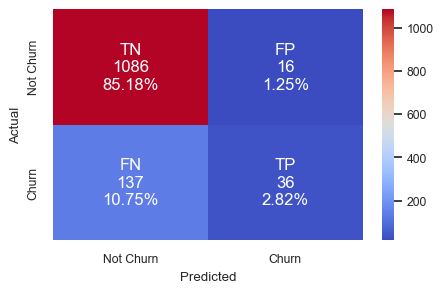

In [40]:
evaluate_model(grid_search)

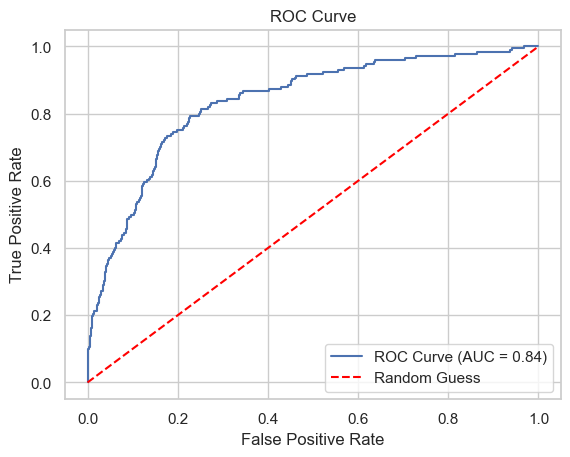

In [41]:
plot_roc_curve(grid_search, X_test, y_test)

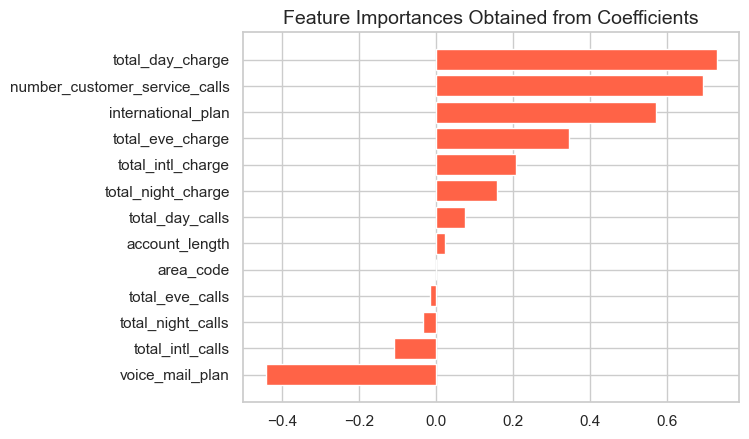

In [42]:
# Feature dataframe
model.fit(X_train, y_train)
importances = pd.DataFrame(data={
    'Attribute': X.columns,
    'Importance': model.coef_[0]})
importances = importances.sort_values(by='Importance', ascending=True)

# -----------------------------------------------------------------------
# Visualization
plt.barh(y=importances['Attribute'], width=importances['Importance'], color='tomato')
plt.title('Feature Importances Obtained from Coefficients', size=14)
plt.show()

### *Random Forest Classifier*
---


In [97]:
from sklearn import model_selection
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, class_weight='balanced',max_depth=5, n_estimators=100)
kfold = model_selection.KFold(n_splits=10,shuffle = True, random_state=42)
rf_model = model_selection.cross_val_score(rf, X, y, cv=kfold, scoring= 'recall')
print('Recall Mean:', rf_model.mean().round(4))
print('Std:', rf_model.std().round(4))

Recall Mean: 0.8193
Std: 0.0602


#### Hyperparameter Tuning

In [98]:
params ={'n_estimators': [100, 200, 300],
         'max_depth': [5, 10, 20],
         'min_samples_split': [2, 5, 10],
         'min_samples_leaf': [1, 2, 4]}

# -------------------------------------------------------------------------------
model = RandomForestClassifier(random_state=42, class_weight='balanced')
kfold = model_selection.StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
grid_search = model_selection.GridSearchCV(model, param_grid = params, scoring = 'recall', cv = kfold)

grid_search.fit(X_train, y_train)
print('Best parameters: ', grid_search.best_params_)

Best parameters:  {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}


#### Predict and Evaluation

MODEL EVALUATION

              precision    recall  f1-score   support

           0       0.97      0.94      0.96      1102
           1       0.70      0.84      0.76       173

    accuracy                           0.93      1275
   macro avg       0.84      0.89      0.86      1275
weighted avg       0.94      0.93      0.93      1275

-------------------------------------------------------
Test ROC-AUC Score : 0.9259
Train ROC-AUC Score: 0.9419
-------------------------------------------------------


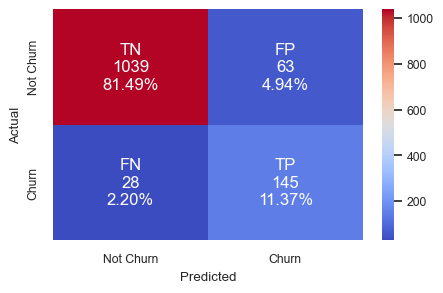

In [45]:
evaluate_model(grid_search)

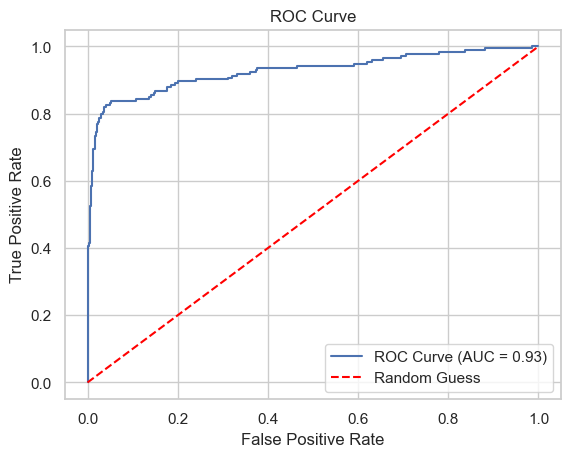

In [46]:
plot_roc_curve(grid_search, X_test, y_test)

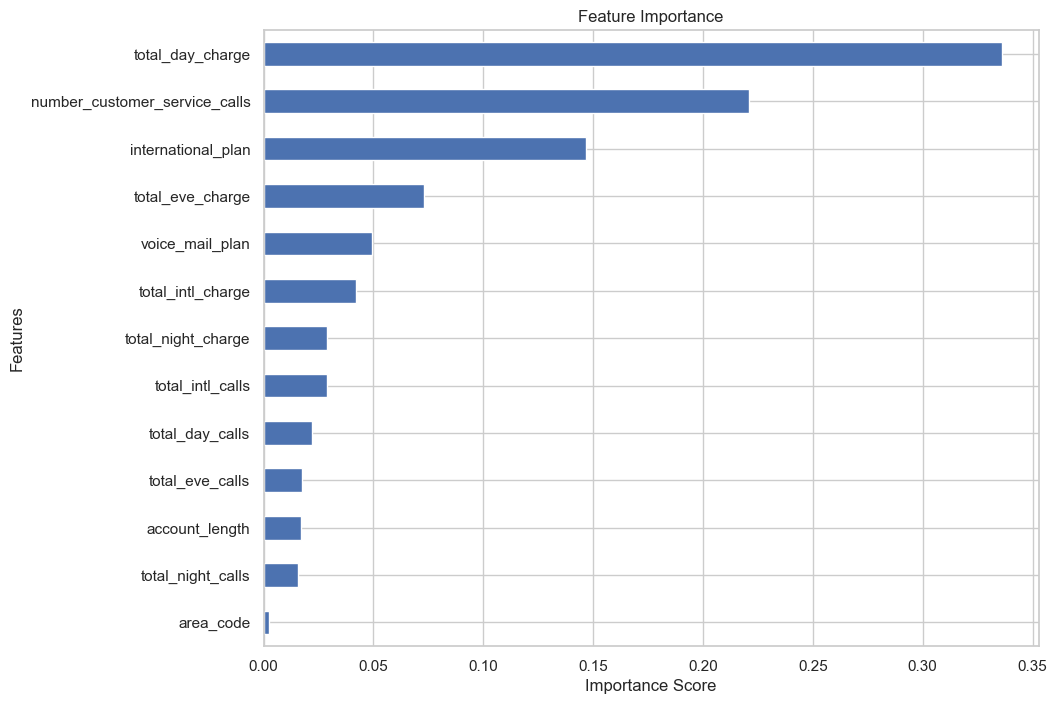

In [47]:
show_feature_importance(grid_search.best_estimator_)

### *XGBoost*
---

In [48]:
from sklearn import model_selection
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
kfold = model_selection.KFold(n_splits=10,shuffle = True, random_state=42)
xgb_model = model_selection.cross_val_score(xgb, X, y, cv=kfold, scoring= 'recall')
print('Recall Mean:', xgb_model.mean().round(4))
print('Std:', xgb_model.std().round(4))

Recall Mean: 0.7803
Std: 0.0464


#### Hyperparameter Tuning

In [49]:
params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 1],
    'n_estimators': [100, 500, 1000],
    'scale_pos_weight': [5, 10, 15] # set the class weight
}

# ----------------------------------------------------------------------
model = XGBClassifier(random_state=42)
kfold = model_selection.StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
grid_search = model_selection.GridSearchCV(model, param_grid = params, scoring = 'recall', cv = kfold)

grid_search.fit(X_train, y_train)
print('Best parameters: ', grid_search.best_params_)

Best parameters:  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 15}


#### Predict and Evaluation

MODEL EVALUATION

              precision    recall  f1-score   support

           0       0.97      0.78      0.87      1102
           1       0.38      0.87      0.53       173

    accuracy                           0.79      1275
   macro avg       0.68      0.82      0.70      1275
weighted avg       0.89      0.79      0.82      1275

-------------------------------------------------------
Test ROC-AUC Score : 0.8945
Train ROC-AUC Score: 0.8994
-------------------------------------------------------


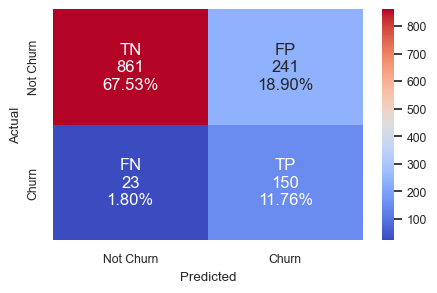

In [50]:
evaluate_model(grid_search)

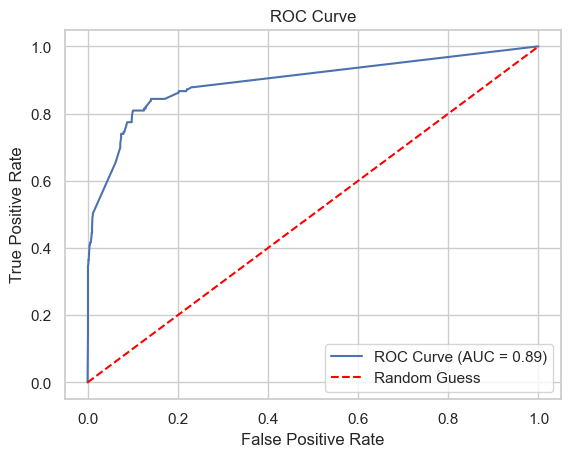

In [51]:
plot_roc_curve(grid_search, X_test, y_test)

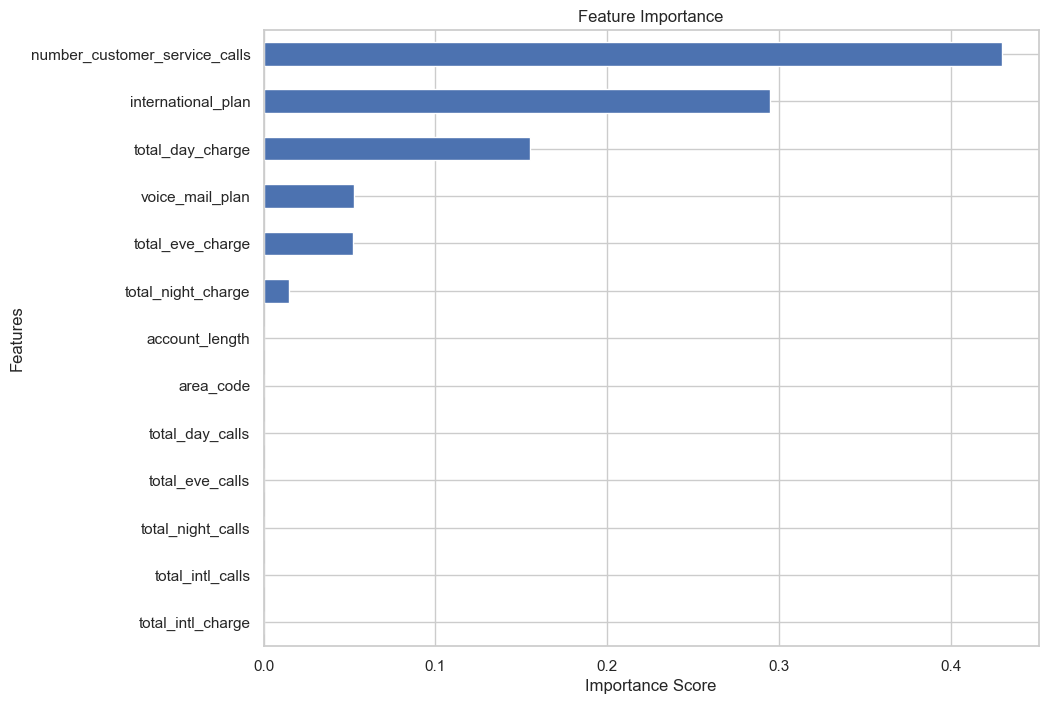

In [52]:
show_feature_importance(grid_search.best_estimator_)

## Final Model
---

### Model Comparison

The performance of different machine learning models is compared using Recall, Test AUC, and Training AUC. The models are then sorted based on Recall, followed by AUC scores, to identify the best-performing model for customer churn prediction.

In [53]:
results = pd.DataFrame([['Logistic Regression', 0.78, 0.84, 0.82],
                       ['Random Forest Classiefier', 0.89, 0.93, 0.94],
                       ['XGBoost Classiefier', 0.86, 0.92, 0.95]],
                        columns = ['Models', 'Recall', 'AUC', 'AUC Train'])

results = results.round({'Recall': 2, 'AUC': 2, 'AUC Train': 2})
results = results.sort_values(by=['Recall', 'AUC', 'AUC Train'], ascending=False)
results

,Models,Recall,AUC,AUC Train
1,Random Forest Classiefier,0.89,0.93,0.94
2,XGBoost Classiefier,0.86,0.92,0.95
0,Logistic Regression,0.78,0.84,0.82


#### SHAP Analysis
---

In [54]:
from IPython.display import clear_output

!pip install shap

clear_output()

In [55]:
import shap

model_final = RandomForestClassifier(random_state=42, 
                               class_weight='balanced',
                               max_depth = 5,
                               min_samples_leaf = 2,
                               min_samples_split = 10,
                               n_estimators = 300)
model_final.fit(X_train, y_train)

explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test)

In [58]:
import pandas as pd

X_test = pd.DataFrame(X_test, columns=X.columns)

In [62]:
shap_exp = shap.Explanation(
    values=shap_values[0, :, 1],
    feature_names=X_test.columns,
    data=X_test.iloc[0],
    base_values=explainer.expected_value[1]
)

In [61]:
print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, "shape") else "No shape")
print(X_test.shape)

<class 'numpy.ndarray'>
(1275, 13, 2)
(1275, 13)


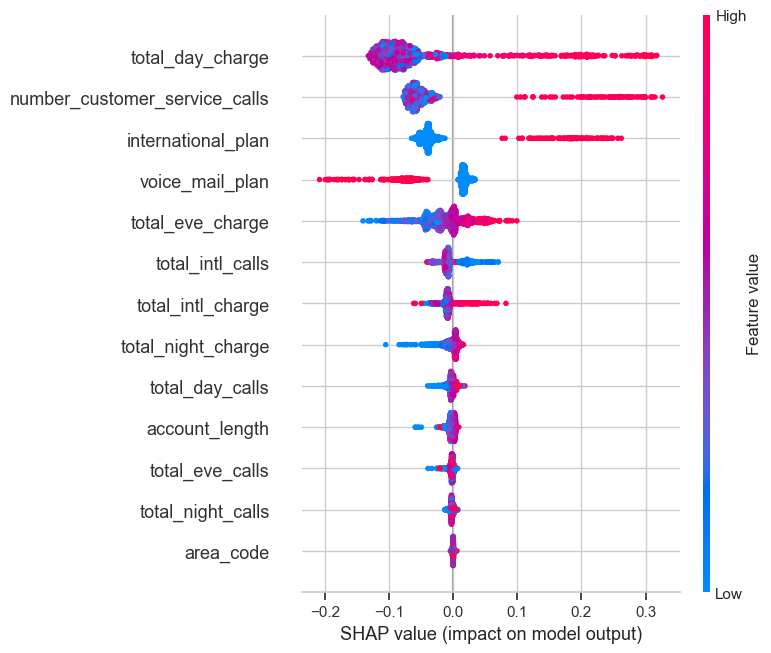

In [64]:
shap.summary_plot(shap_values[:, :, 1], X_test)

# **Predict Data Test**

### Data Test Overview

In [66]:
# load data test
df_test = pd.read_csv("Data_Test.csv")

In [67]:
df_test.sample(3)

,id,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
494,495,WA,84,area_code_415,no,no,0,289.1,100,49.15,233.8,97,19.87,223.5,148,10.06,12.7,2,3.43,2
694,695,MN,76,area_code_415,no,no,0,168.4,74,28.63,161.0,83,13.69,147.4,117,6.63,8.0,4,2.16,1
569,570,MN,167,area_code_415,yes,no,0,143.7,108,24.43,75.6,111,6.43,217.9,99,9.81,9.9,4,2.67,0


In [68]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             750 non-null    int64  
 1   state                          750 non-null    object 
 2   account_length                 750 non-null    int64  
 3   area_code                      750 non-null    object 
 4   international_plan             750 non-null    object 
 5   voice_mail_plan                750 non-null    object 
 6   number_vmail_messages          750 non-null    int64  
 7   total_day_minutes              750 non-null    float64
 8   total_day_calls                750 non-null    int64  
 9   total_day_charge               750 non-null    float64
 10  total_eve_minutes              750 non-null    float64
 11  total_eve_calls                750 non-null    int64  
 12  total_eve_charge               750 non-null    flo

In [69]:
df_test.duplicated().sum()

np.int64(0)

- tidak ada duplikat dan missing value

## Data Test Preparation
---

In [76]:
%whos

Variable                  Type                      Data/Info
-------------------------------------------------------------
LabelEncoder              type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LogisticRegression        type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier    ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler            type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                         DataFrame                 Shape: (4250, 13)
XGBClassifier             type                      <class 'xgboost.sklearn.XGBClassifier'>
X_test                    DataFrame                 Shape: (1275, 13)
X_train                   ndarray                   2975x13: 38675 elems, type `float64`, 309400 bytes (302.1484375 kb)
ax                        Axes                      Axes(0.125,0.11;0.775x0.77)
categorical 

In [78]:
df_test.columns

Index(['id', 'state', 'account_length', 'area_code', 'international_plan',
       'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes',
       'total_day_calls', 'total_day_charge', 'total_eve_minutes',
       'total_eve_calls', 'total_eve_charge', 'total_night_minutes',
       'total_night_calls', 'total_night_charge', 'total_intl_minutes',
       'total_intl_calls', 'total_intl_charge',
       'number_customer_service_calls'],
      dtype='object')

In [79]:
feats =['account_length', 'area_code', 'international_plan', 'voice_mail_plan', 'total_day_calls', 'total_day_charge', 'total_eve_calls',
        'total_eve_charge', 'total_night_calls', 'total_night_charge', 'total_intl_calls', 'total_intl_charge', 'number_customer_service_calls']
X_test1 = df_test[feats]

In [80]:
le = LabelEncoder()
# ----------------------
for col in X_test1.columns:
    if X_test1[col].dtype == 'O':
        X_test1[col] = le.fit_transform(X_test1[col])

In [81]:
scaler = StandardScaler()
X_test1 = pd.DataFrame(scaler.fit_transform(X_test1), columns=X_test1.columns)

## Predict Data Test

In [82]:
model_rf = RandomForestClassifier(random_state=42, 
                               class_weight='balanced',
                               max_depth = 5,
                               min_samples_leaf = 2,
                               min_samples_split = 10,
                               n_estimators = 300)
model_rf.fit(X_train, y_train)
prediction = model_rf.predict(X_test1)

In [84]:
df_test1 = pd.read_csv("Data_Test.csv")
submission = pd.DataFrame({
        'id': df_test1['id'],
        'churn': prediction
    })
submission.head()

,id,churn
0,1,0
1,2,1
2,3,1
3,4,0
4,5,0


In [85]:
submission.to_csv('submit.csv', index = False)

In [86]:
df_test['churn'] = submission['churn']
df_test.head()

,id,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,1,KS,128,area_code_415,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,2,AL,118,area_code_510,yes,no,0,223.4,98,37.98,...,101,18.75,203.9,118,9.18,6.3,6,1.70,0,1
2,3,IA,62,area_code_415,no,no,0,120.7,70,20.52,...,76,26.11,203.0,99,9.14,13.1,6,3.54,4,1
3,4,VT,93,area_code_510,no,no,0,190.7,114,32.42,...,111,18.55,129.6,121,5.83,8.1,3,2.19,3,0
4,5,NE,174,area_code_415,no,no,0,124.3,76,21.13,...,112,23.55,250.7,115,11.28,15.5,5,4.19,3,0


In [87]:
df_test.to_csv('final.csv', index = False)

In [88]:
import joblib

joblib.dump(model_final, "model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Scaler and LabelEncoder saved successfully!")

Scaler and LabelEncoder saved successfully!
